# shooting optimal control pendulum w/ autodiff

- TODO: underactuated control constraints

In [1]:
import matplotlib.pyplot as plt
from trexdiff import Node, sin, cos, log, tensor2d, relu
import numpy as np
import matplotlib

In [2]:
# same time horizon, different T, dt
5e-2 * 10, 5e-3 * 100, 1e-2 * 50, 2e-2 * 25

(0.5, 0.5, 0.5, 0.5)

In [3]:
g = 9.81
dt = 1e-2
p5 = 0.5

T = 50

x0 = [
    Node(tensor2d([[0.0]])), # theta
    Node(tensor2d([[0.0]])), # theta_dot
]

# m = 1.0
# l = 1.0

def f(x, dx, u, dt):
    # pendulum forward dynamics
    # we don't support indexing, so have to use x/dx
    # x - theta, dx - theta_dot
    
    theta_ddot = u - g * sin(x)

    # implicit Euler
    x_new = x + dx * dt + theta_ddot * (0.5 * dt ** 2)
    dx_new = dx + theta_ddot * dt
    return x_new, dx_new

xs = [x0]
us = []
for i in range(T):
    u = Node(tensor2d([[0.0]]))
    us.append(u)

    x_new, dx_new = f(xs[-1][0], xs[-1][1], u, dt)
    xs.append((x_new, dx_new))


In [4]:
# loss is squared distance to upright position at final time step
target = Node(tensor2d([[np.pi]]))
Qf = 1e5
U_LIM = 50.0

loss = Qf * (xs[-1][0] - target) * (xs[-1][0] - target) + Qf * (xs[-1][1] * xs[-1][1])

for u in us:
    loss = loss + 1e0 * relu(u * u - U_LIM * U_LIM)


In [5]:
loss.forward()

In [6]:
# gradient descent over the control inputs
learning_rate = 5e-4
losses = []

for i in range(20_000):
    loss.zerograd()
    loss.forward()
    loss.backward()

    if i % 1000 == 0:
        print(f"iter {i}, loss {loss.val[0,0]:.3f}")

    for u in us:
        u.val -= learning_rate * u.grad

    losses.append(loss.val[0,0])

iter 0, loss 986960.440
iter 1000, loss 4503.752
iter 2000, loss 1731.973
iter 3000, loss 1052.188
iter 4000, loss 754.322
iter 5000, loss 592.489
iter 6000, loss 484.897
iter 7000, loss 412.426
iter 8000, loss 356.912
iter 9000, loss 320.752
iter 10000, loss 290.678
iter 11000, loss 262.279
iter 12000, loss 244.584
iter 13000, loss 226.456
iter 14000, loss 211.575
iter 15000, loss 198.849
iter 16000, loss 189.075
iter 17000, loss 181.313
iter 18000, loss 171.924
iter 19000, loss 162.822


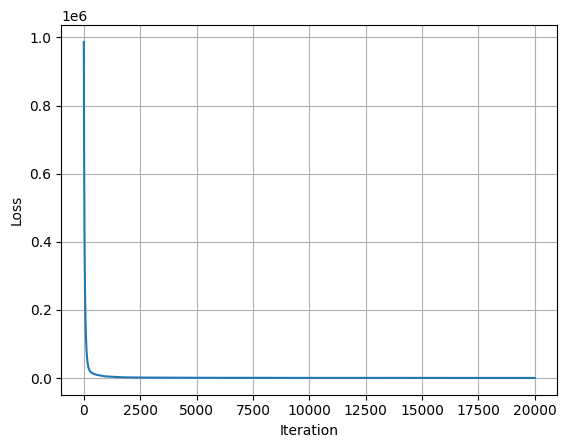

In [7]:
# loss plot
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [8]:
xs[-1]

(Node(val=tensor2d([
   [3.10]
 ]), grad=tensor2d([
   [-7807.81]
 ])),
 Node(val=tensor2d([
   [0.01]
 ]), grad=tensor2d([
   [1316.68]
 ])))

Text(0.5, 1.0, 'Control input over time')

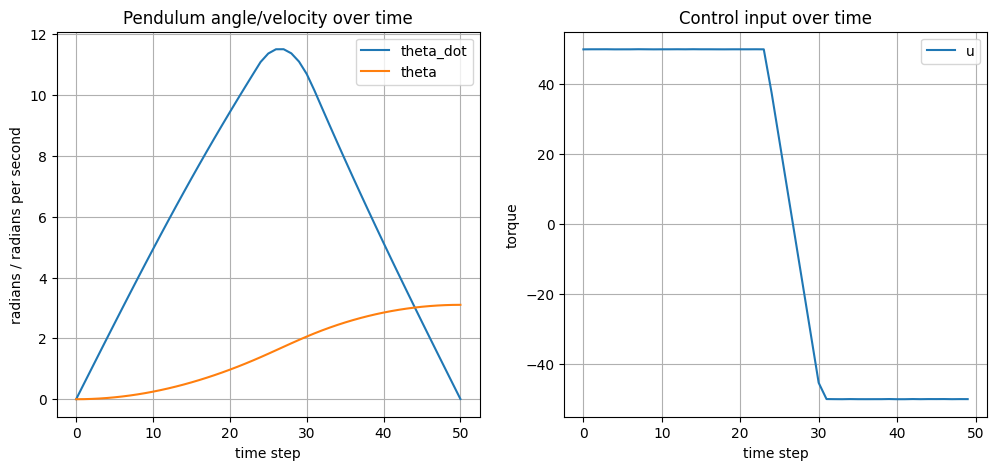

In [9]:
plt.subplots(1,2, figsize=(12,5))

# plot x, x_dot
thetas = [x[0].val[0,0] for x in xs]
theta_dots = [x[1].val[0,0] for x in xs]

plt.subplot(1,2,1)

plt.plot(theta_dots, label="theta_dot")
plt.plot(thetas, label="theta")

plt.xlabel("time step")
plt.ylabel("radians / radians per second")
plt.grid()
plt.legend()
plt.title("Pendulum angle/velocity over time")

# plot control inputs
plt.subplot(1,2,2)
us_plot = [u.val[0,0] for u in us]
plt.plot(us_plot, label="u")
plt.xlabel("time step")
plt.ylabel("torque")
plt.grid()
plt.legend()
plt.title("Control input over time")


In [10]:
import matplotlib.animation as animation
import os
from IPython.display import HTML, display

L = 1.0  # pendulum arm length

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title("Pendulum (optimal control)")

rod,       = ax.plot([], [], 'k-', lw=2)
bob,       = ax.plot([], [], 'o', color='steelblue', ms=14)
pivot,     = ax.plot([0], [0], 'k.', ms=8)
time_text  = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=9)

# hold final frame for 1 s (20 extra frames at 50 ms each) before looping
HOLD_FRAMES = 20
padded_thetas = thetas + [thetas[-1]] * HOLD_FRAMES

def _init():
    rod.set_data([], [])
    bob.set_data([], [])
    time_text.set_text('')
    return rod, bob, time_text

def _animate(i):
    theta = padded_thetas[i]
    bx = L * np.sin(theta)
    by = -L * np.cos(theta)
    rod.set_data([0, bx], [0, by])
    bob.set_data([bx], [by])
    step = min(i, len(thetas) - 1)
    time_text.set_text(f't = {step} steps')
    return rod, bob, time_text

ani = animation.FuncAnimation(
    fig, _animate, init_func=_init,
    frames=len(padded_thetas), interval=50, blit=True
)

os.makedirs("figures", exist_ok=True)
out_path = "figures/pendulum.gif"
ani.save(out_path, writer=animation.PillowWriter(fps=20))
print(f"Saved animation to {os.path.abspath(out_path)}")

display(HTML(ani.to_jshtml()))
plt.close(fig)


Saved animation to /home/tdinev/projects/personal/trexdiff/examples/figures/pendulum.gif
